
## How to Use the Notebooks

To run these notebooks, follow these steps:


### 1. Install **`gdal`** Package
Installing `gdal` via `pip` may fail. Therefore, we recommend using conda to install it:
```bash
conda install gdal -c conda-forge
```

### 2. Install **`polsartools`** Package

Before running the notebooks, you'll need to install the core **`polsartools`** package. 

**Option A:** Install from PyPI `pip` (stable release)

```bash
pip install polsartools
```

**Option B:** Install from conda (stable release)

```bash
conda install polsartools -c bnarayanarao
```


**Option C:**  Install the latest version from GitHub (if you need recent updates or fixes)

```bash
pip install git+https://github.com/Narayana-Rao/polsartools.git#egg=polsartools
```
> **Note:** If you encounter a `"module not found"` error or require newer features, prefer the **Option C**.

### 3. Verify the Installation

After successfully installing `polsartools`, you can verify it by importing the package:

```bash
import polsartools as pst
```

If this runs without errors, you're ready to explore and run the notebooks.




In [1]:
import polsartools as pst
import os
from osgeo import gdal
import matplotlib.pyplot as plt
import numpy as np


In [2]:
""" 

Function to display images

"""

def plot_images(*filenames, lower_percentile=2, upper_percentile=98, max_cols=4):
    def compute_vmin_vmax(data):
        data_no_nan = data[np.isfinite(data)]
        vmin = np.percentile(data_no_nan, lower_percentile)
        vmax = np.percentile(data_no_nan, upper_percentile)
        return vmin, vmax

    num_images = len(filenames)

    if num_images == 1:
        # Single image case
        data = pst.read_rst(filenames[0])
        data[data==0]=np.nan
        vmin, vmax = compute_vmin_vmax(data)

        fig, ax = plt.subplots(figsize=(6, 6))
        im = ax.imshow(data, vmin=vmin, vmax=vmax)
        ax.set_title(os.path.basename(filenames[0]))
        fig.colorbar(im, ax=ax)
        plt.tight_layout()
        plt.show()
    else:
        # Multiple image case
        ncols = min(max_cols, num_images)
        nrows = int(np.ceil(num_images / ncols))

        fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows))
        axes = np.array(axes).reshape(-1)  # Flatten in case it's a 2D grid

        for i, filename in enumerate(filenames):
            data = pst.read_rst(filename)
            data[data==0]=np.nan
            vmin, vmax = compute_vmin_vmax(data)
            ax = axes[i]
            im = ax.imshow(data, vmin=vmin, vmax=vmax)
            ax.set_title(os.path.basename(filename))
            fig.colorbar(im, ax=ax)

        for j in range(num_images, len(axes)):
            axes[j].axis('off')

        plt.tight_layout()
        plt.show()


#### Extract GRD backscatter intensity files

In [3]:
# Provide path to the extracted folder
in_dir = r"./s1/S1A_IW_GRDH_1SDV_20251107T003033_20251107T003058_061764_07B83B_9183.SAFE"

#The following function extracts GRD intensity files from Sentinel-1 GRD data

pst.s1_grd(in_dir, bsc="sigma0",dB=False,pols=['vv','vh'],geocode=True)


vv: Geocode using GCPs: 100%|███████████████████████████████████████████████████████| 4/4 [00:24<00:00,  6.10s/step]


Saved file: ./s1/S1A_IW_GRDH_1SDV_20251107T003033_20251107T003058_061764_07B83B_9183.SAFE/processed/vv_sigma0_lin_geo.tif


vh: Geocode using GCPs: 100%|███████████████████████████████████████████████████████| 4/4 [00:25<00:00,  6.31s/step]

Saved file: ./s1/S1A_IW_GRDH_1SDV_20251107T003033_20251107T003058_061764_07B83B_9183.SAFE/processed/vh_sigma0_lin_geo.tif


#### Generate Degree of polarization (DoP)

In [13]:
proc_dir = os.path.join(in_dir,"processed")

cpFile = os.path.join(proc_dir,"vv_sigma0_lin_geo.tif")
xpFile = os.path.join(proc_dir,"vh_sigma0_lin_geo.tif")

pst.dprvic(cpFile,xpFile,win=3)

Progress: 100%|█████████████████████████████████████████████████████████████████| 24/24 [00:00<00:00, 279.88block/s]

Saved file ./s1/S1A_IW_GRDH_1SDV_20251107T003033_20251107T003058_061764_07B83B_9183.SAFE/processed/dprvic.tif
Execution time for dprvic: 0.00 seconds


#### Display Dual-pol Radar Vegetation Index for GRD data (DpRVIc)

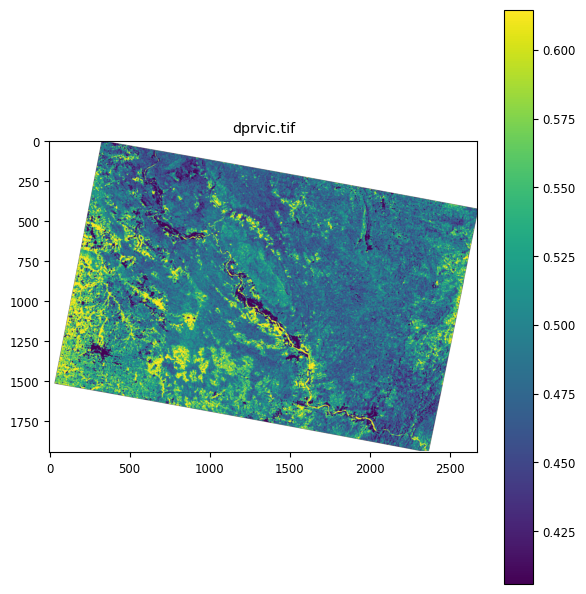

In [14]:

plot_images(os.path.join(proc_dir,'dprvic.tif'))


#### Generate Dual-pol descriptors

In [15]:
pst.dp_desc(cpFile,xpFile,win=3)

Progress: 100%|█████████████████████████████████████████████████████████████████| 24/24 [00:00<00:00, 172.23block/s]


Saved file ./s1/S1A_IW_GRDH_1SDV_20251107T003033_20251107T003058_061764_07B83B_9183.SAFE/processed/mc.tif
Saved file ./s1/S1A_IW_GRDH_1SDV_20251107T003033_20251107T003058_061764_07B83B_9183.SAFE/processed/Hc.tif
Saved file ./s1/S1A_IW_GRDH_1SDV_20251107T003033_20251107T003058_061764_07B83B_9183.SAFE/processed/Thetac.tif
Execution time for dp_desc: 0.00 seconds


#### Display descriptors

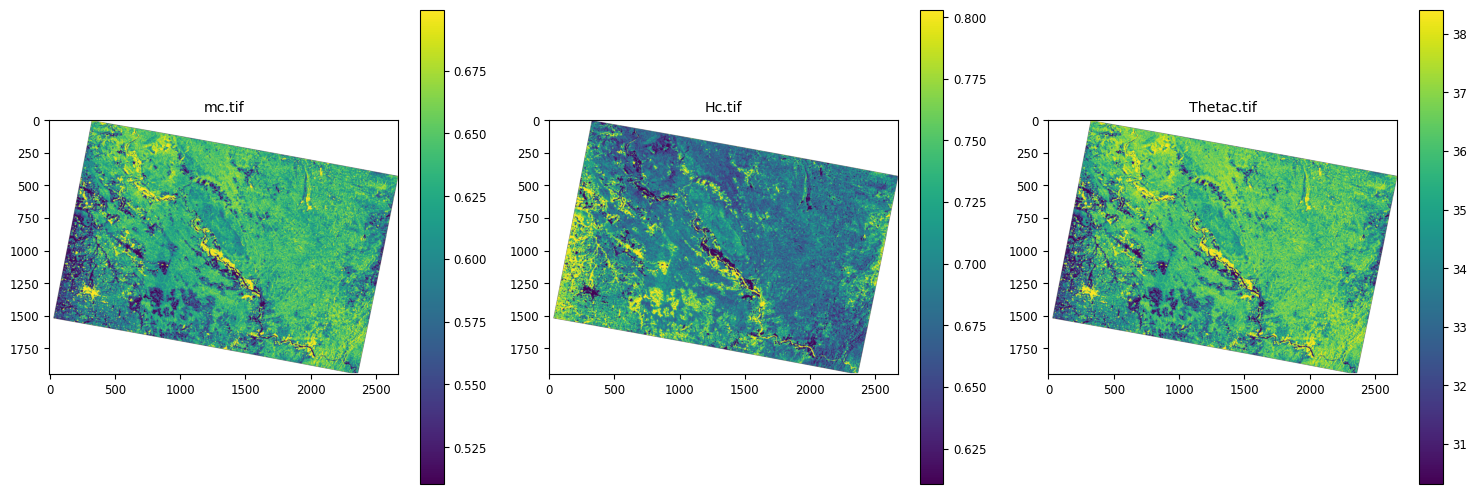

In [17]:

plot_images(os.path.join(proc_dir,'mc.tif'),
            os.path.join(proc_dir,'Hc.tif'),
            os.path.join(proc_dir,'Thetac.tif'),
           )

